In [31]:
%load_ext autoreload
%autoreload 2
from data_preparation import get_data_from_Kaggle, divide_into_img_gt, concat_folders, \
    rename_folder, rename_files_in_folder, rename_files_sequentialy, rename_folders_sequentialy, \
    flatten_folders, split_test_val_test, create_density_map
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy
import PIL.Image as Image

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Fetching data

In [ ]:
destination_path = r"E:\OneDrive\Pulpit\MSC-thesis\data"
datasets = ["tthien/shanghaitech", "tthien/ucfcc50", "anhhhhtx/ucf-qnrf"]
for dataset in datasets:
    get_data_from_Kaggle(dataset, destination_path)

### Changing folder hierarchy

In [8]:
paths = [r"data\UCF-QNRF_ECCV18\Test",
         r"data\UCF-QNRF_ECCV18\Train",
         r"data\UCF_CC_50"]
for path in paths:
    divide_into_img_gt(path)

In [12]:
concat_folders(r"data\NWPU-Crowd")

In [14]:
rename_folder(r'data\NWPU-Crowd\mats', 'matrices')
rename_files_in_folder(r'data\NWPU-Crowd\matrices')

In [4]:
rename_files_sequentialy(r'data\ShanghaiTech')

In [ ]:
rename_folders_sequentialy(r'data\ShanghaiTech')


In [12]:
rename_folders_sequentialy(r'data\ShanghaiTech', 'ground-truth', 'matrices')

In [14]:
flatten_folders(r'data\ShanghaiTech')

In [ ]:
split_test_val_test(r'data\NWPU-Crowd')

In [29]:
rename_folders_sequentialy(r'data\jhu_crowd_v2.0', 'gt', 'matrices')
rename_files_sequentialy(r'data\jhu_crowd_v2.0', folder='matrices', prefix='ann_')

<unknown>:87: SyntaxWarning: invalid escape sequence '\{'
<unknown>:87: SyntaxWarning: invalid escape sequence '\{'


### Creating density maps

In [49]:
img = plt.imread(r'data\ShanghaiTech_part_B\test\images\IMG_1.jpg')
mat = scipy.io.loadmat(r'data\ShanghaiTech_part_B\test\matrices\ann_GT_IMG_1.mat')
points = mat['image_info']
map = create_density_map(img,points[0,0][0,0][0], k=3)

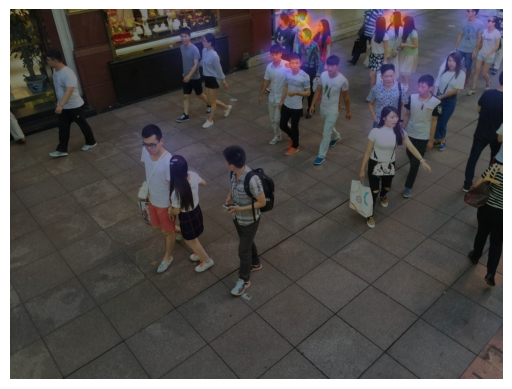

21.09606678536528


In [50]:
img = Image.open(r'data\ShanghaiTech_part_B\test\images\IMG_1.jpg')

plt.imshow(img)
plt.imshow(map, cmap='CMRmap', alpha=0.5)

plt.axis('off')
plt.show()

print(np.sum(map))